In [ ]:
# %%[markdown]
# Lets declare and import the needed tools for analyzing the data.

In [ ]:

from logging import error
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from chardet import detect
import seaborn as sns

def get_encoding_type(file):
    with open(file, 'rb') as f:
        rawdata = f.read()
    return detect(rawdata)['encoding']

def normalize_column_and_fields(df: pd.DataFrame, column: str, new_column: str = 'municipality'):
    if column not in df.columns:
        print(f"Skipping normalization: no column {column!r}")
        return df

    df = df.copy()
    df.rename(columns={column: new_column}, inplace=True)

    df[new_column] = (
        df[new_column]
        .astype(str)
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.title()
    )

    return df

def sanitize_numeric_columns(df: pd.DataFrame, columns):
    df = df.copy()
    for col in columns:
        if col not in df.columns:
            print(f"Skipping missing column: {col!r}")
            continue

        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.replace(r"[^\d\.\-]", "", regex=True)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


# %%[markdown]
# ## Read
# Read files into dataframes

In [ ]:

mun_file = './Kunta.csv'
mun = csv = pd.read_csv(mun_file, encoding=get_encoding_type(mun_file))



bed_file = './001_117s_2026_20260328-104522.csv'
bed = csv = pd.read_csv(bed_file, encoding=get_encoding_type(bed_file))



road_file = './001_12jz_2024_20260328-105719.csv'
road = csv = pd.read_csv(road_file, encoding=get_encoding_type(road_file))

## Normalization
Now that we have all the needed data loaded, it would be good to normalize.

In [6]:

mun = normalize_column_and_fields(mun, 'namefin')
bed = normalize_column_and_fields(bed, 'Municipality')
road = normalize_column_and_fields(road, 'Alue')

print(mun.columns)
print(bed.columns)
print(road.columns)

Skipping normalization: no column 'namefin'
Skipping normalization: no column 'Municipality'
Skipping normalization: no column 'Alue'
Index(['id', 'gml_id', 'natcode', 'municipality', 'nameswe', 'landarea',
       'freshwarea', 'seawarea', 'totalarea'],
      dtype='str')
Index(['municipality', 'Type of accommodation establishment',
       'Number of bed-places 2026*'],
      dtype='str')
Index(['municipality', 'Tieluokka', 'Päällyste', 'Vuosi', 'Tiepituus'], dtype='str')


## Merge
Merge the dataframes into one.

In [ ]:

df = pd.merge(mun, bed, on='municipality', how='left')
df = pd.merge(df, road, on='municipality', how='left')

## Sanitize values
Finally before we create new coluns the values would be good to santize and normalize

In [ ]:
df = sanitize_numeric_columns(df, ["landarea", "Tiepituus", "Number of bed-places 2026*"])

df["Road density"] = np.where(
    df["landarea"] != 0,
    df["Tiepituus"] / df["landarea"],
    np.nan
)

df["Tourism density"] = np.where(
    df["landarea"] != 0,
    df["Number of bed-places 2026*"] / df["landarea"],
    np.nan
)


Mean, median, minimum, maximum and standard deviation in new columns

In [12]:

summary = df[["Road density", "Tourism density"]].agg([
    "mean", "median", "min", "max", "std"
])

print(summary)

        Road density  Tourism density
mean        0.365084         2.669812
median      0.364867         0.509644
min         0.046117         0.025310
max         0.799148       129.546090
std         0.127230        11.626491


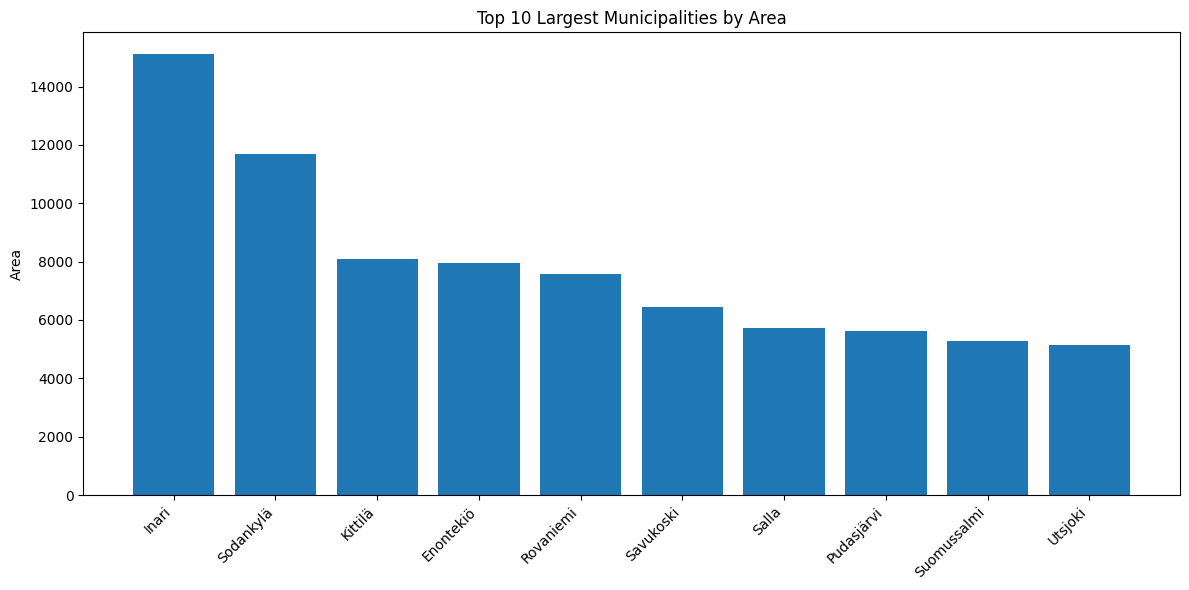

In [14]:

top_area = df.nlargest(10, "landarea")

plt.figure(figsize=(12, 6))
plt.bar(top_area["municipality"], top_area["landarea"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Area")
plt.title("Top 10 Largest Municipalities by Area")
plt.tight_layout()
plt.show()

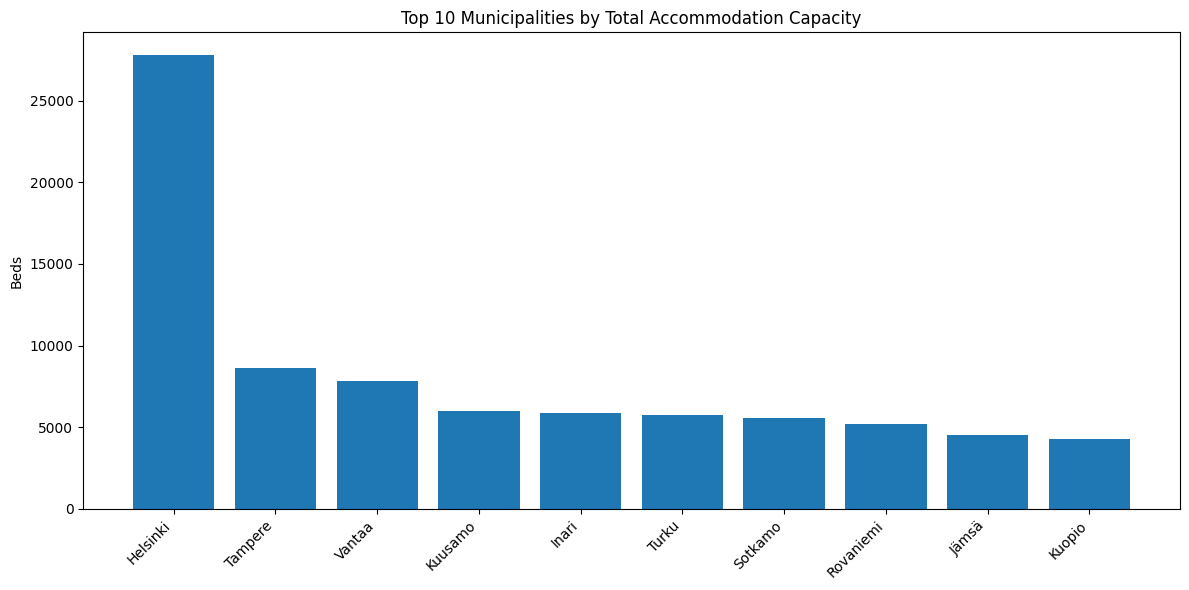

In [16]:

top_beds = df.nlargest(10, "Number of bed-places 2026*")

plt.figure(figsize=(12, 6))
plt.bar(top_beds["municipality"], top_beds["Number of bed-places 2026*"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Beds")
plt.title("Top 10 Municipalities by Total Accommodation Capacity")
plt.tight_layout()
plt.show()

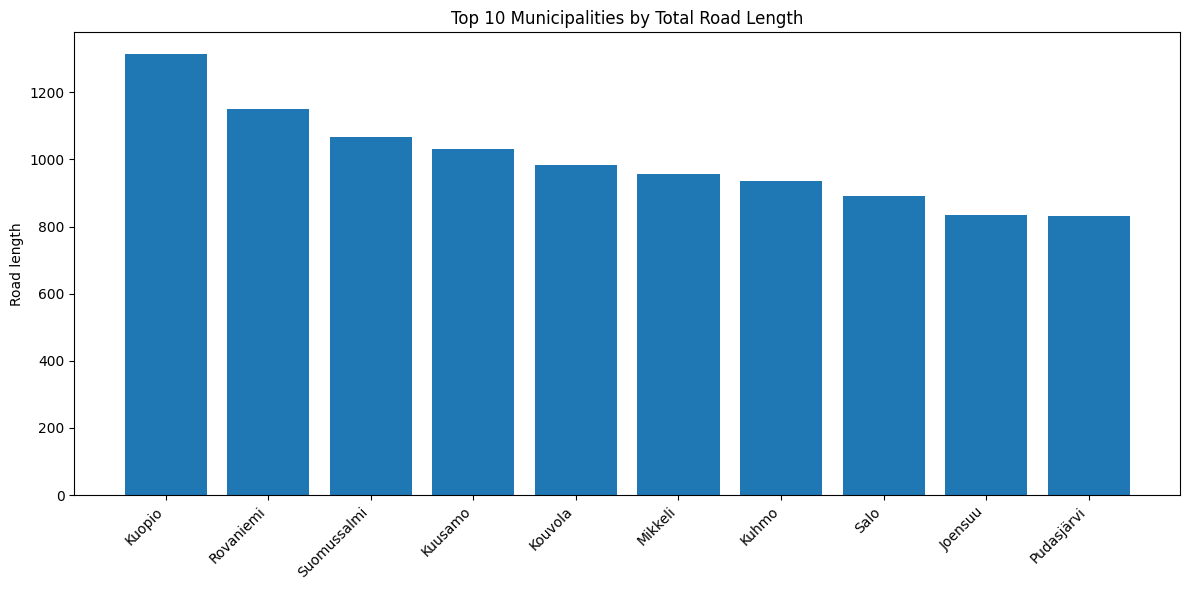

In [18]:

top_roads = df.nlargest(10, "Tiepituus")

plt.figure(figsize=(12, 6))
plt.bar(top_roads["municipality"], top_roads["Tiepituus"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Road length")
plt.title("Top 10 Municipalities by Total Road Length")
plt.tight_layout()
plt.show()

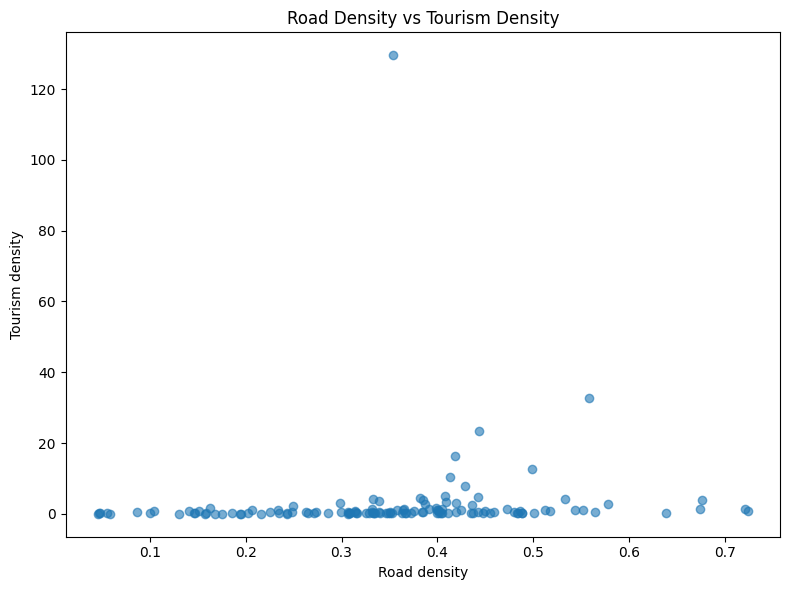

In [20]:

plt.figure(figsize=(8, 6))
plt.scatter(df["Road density"], df["Tourism density"], alpha=0.6)
plt.xlabel("Road density")
plt.ylabel("Tourism density")
plt.title("Road Density vs Tourism Density")
plt.tight_layout()
plt.show()

In [ ]:

# AI generoitu kuntalista: GPT-5.4 mini - sort out the municipalities in lappland region from dataframe without region column
lapland_municipalities = [
    "Enontekiö", "Inari", "Kemi", "Kemijärvi", "Keminmaa", "Kittilä",
    "Kolari", "Muonio", "Pelkosenniemi", "Pello", "Posio", "Ranua",
    "Rovaniemi", "Salla", "Savukoski", "Simo", "Sodankylä", "Tervola",
    "Tornio", "Utsjoki", "Ylitornio"
]

lapland = df[df["municipality"].isin(lapland_municipalities)].copy()
lapland = lapland.dropna(subset=["Number of bed-places 2026*"])

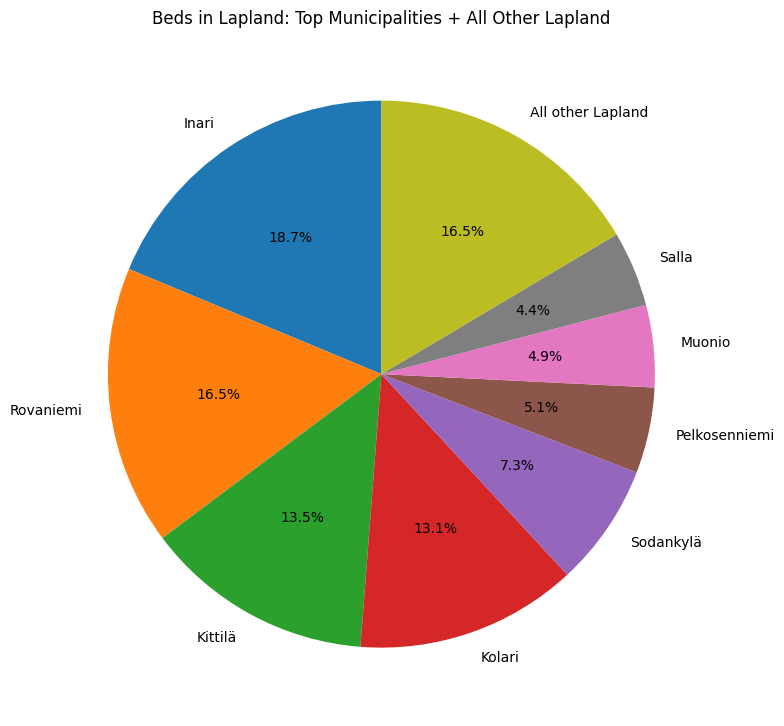

In [24]:


top_lapland = lapland.nlargest(8, "Number of bed-places 2026*")
other_sum = lapland["Number of bed-places 2026*"].sum() - top_lapland["Number of bed-places 2026*"].sum()

pie_data = pd.concat([
    top_lapland[["municipality", "Number of bed-places 2026*"]],
    pd.DataFrame([{"municipality": "All other Lapland", "Number of bed-places 2026*": other_sum}])
])


plt.figure(figsize=(8, 8))
plt.pie(
    pie_data["Number of bed-places 2026*"],
    labels=pie_data["municipality"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Beds in Lapland: Top Municipalities + All Other Lapland")
plt.tight_layout()
plt.show()

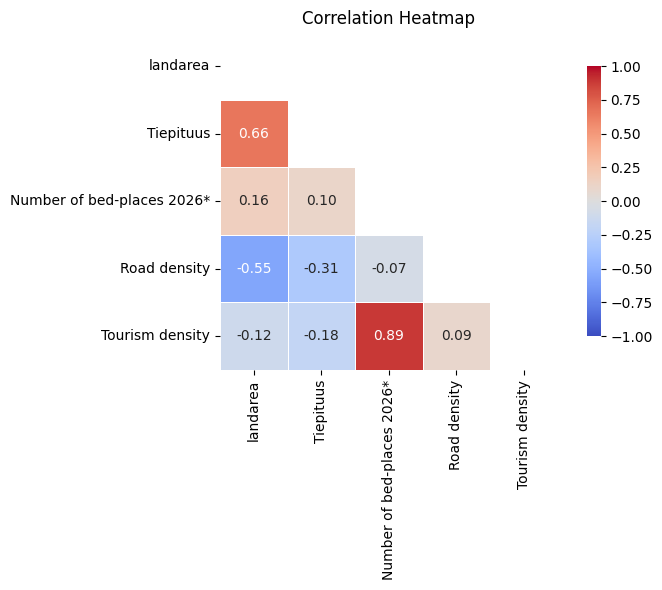

In [25]:


corr = df[["landarea", "Tiepituus", "Number of bed-places 2026*", "Road density", "Tourism density"]].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()